In [5]:
# LangChain 업데이트
# !python -m pip install -r https://raw.githubusercontent.com/teddylee777/langchain-kr/main/requirements.txt

!python -m pip install -U langchain-openai

!python -m pip install -qU langchain-teddynote



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


🤖 AI response:
──────────────────────────────────────────────────
[1] 📊 CURRENT SITUATION
- The USD/UZS exchange rate has experienced moderate upward pressure recently, reflecting a slight depreciation of the Uzbekistani Som against the US Dollar.
- Over the past few weeks, the rate has shown a gradual increase, driven by domestic macroeconomic adjustments and external factors.

[2] 🔍 KEY FACTORS
- US Federal Reserve monetary policy: ↑ USD — Anticipated rate hikes or hawkish signals tend to strengthen the USD globally, exerting upward pressure on USD/UZS.
- Uzbekistan's trade balance and remittances: ↓ UZS — A widening trade deficit or reduced remittance inflows can weaken the Som, pushing USD/UZS higher.
- Domestic inflation and central bank policy: ↑ UZS — If Uzbekistan maintains or tightens monetary policy to combat inflation, it could support the Som, exerting downward pressure on USD/UZS.
- Global USD strength (DXY index): ↑ USD — A rising DXY index indicates a stronger USD, likel

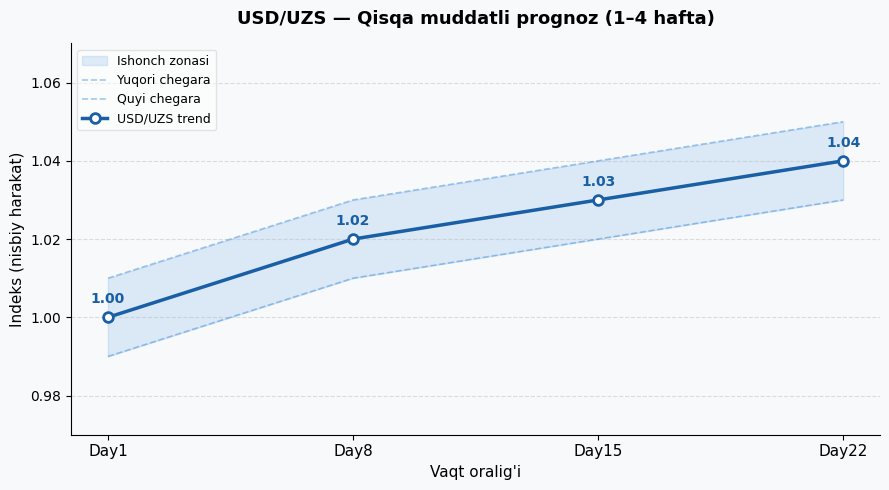

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_teddynote.models import MultiModal
from langchain_teddynote.messages import stream_response
import re
import json
import matplotlib.pyplot as plt
import numpy as np

# ──────────────────────────────────────────────
# 1. LLM sozlash
# ──────────────────────────────────────────────
llm = ChatOpenAI(
    api_key="OPENAI_API_KEY",
    temperature=0.1,
    model_name="gpt-4.1-nano",
)

system_prompt = """
You are a professional financial analyst AI specializing in foreign exchange (Forex), macroeconomics, and emerging market currencies, especially Uzbekistani Som (UZS) and US Dollar (USD).

Your task is to analyze provided data (news, macroeconomic indicators, historical exchange rates, geopolitical events, and market sentiment) and produce a probabilistic forecast of USD/UZS exchange rate movement.

Follow these strict rules:

1. ANALYSIS DEPTH
- Always analyze from multiple perspectives:
  • Macroeconomic factors (inflation, interest rates, GDP, central bank policy)
  • Political/geopolitical events
  • Global USD strength (DXY trends, Fed policy)
  • Local Uzbekistan factors (trade balance, remittances, government policy)
  • Market sentiment (news tone: positive/negative/neutral)

2. OUTPUT STRUCTURE (MANDATORY)

Return response in this exact format:

[1] 📊 CURRENT SITUATION
- Brief summary of current USD/UZS state
- Key recent movements

[2] 🔍 KEY FACTORS
- List 3–6 main factors affecting the exchange rate
- For each factor: explain impact direction (↑ USD or ↓ USD)

[3] 📈 PROBABILISTIC FORECAST (SHORT TERM: 1–4 weeks)
- USD Up probability: XX%
- USD Down probability: XX%
- Sideways probability: XX%

[4] 📉 MID-TERM OUTLOOK (1–3 months)
- Trend: (Bullish USD / Bearish USD / Neutral)
- Confidence level: Low / Medium / High
- Explanation (2–3 sentences)

[5] 📊 GRAPH DATA (IMPORTANT)
Return forecasted trend as structured data for plotting:

{
  "timeline": ["Day1", "Day2", ..., "Day7"],
  "usd_uzs_trend": [float, float, ...],
  "confidence_band_upper": [...],
  "confidence_band_lower": [...]
}

- Values should represent relative movement (index-based, not exact rate)
- Use realistic smooth trends (no random spikes)

[6] ⚠️ RISKS & UNCERTAINTY
- List major risks that could invalidate the forecast

3. STYLE RULES
- Be analytical, not emotional
- Do NOT give absolute predictions
- Always use probabilities
- Avoid vague statements like "maybe" — quantify uncertainty

4. IMPORTANT CONSTRAINTS
- Do NOT fabricate exact numerical exchange rates unless provided
- Do NOT claim certainty
- If data is insufficient, say so clearly

5. GOAL
Provide realistic, data-driven probabilistic insight suitable for decision support — NOT financial advice.
"""

user_prompt = """
Please analyze the current USD/UZS exchange rate situation and provide a probabilistic forecast for the next 1–4 weeks, along with a mid-term outlook for the next 1–3 months. Include key factors influencing the exchange rate and any major risks that could affect your forecast.
"""

# ──────────────────────────────────────────────
# 2. ✅ TO'G'RI USUL — stream ni qo'lda yig'ish
#    stream_response() faqat print qiladi, None qaytaradi
#    Shuning uchun chunk larni o'zimiz yig'amiz
# ──────────────────────────────────────────────
stream = llm.stream([
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_prompt}
])

print("🤖 AI response:\n" + "─" * 50)
chunks = []
for chunk in stream:
    text = chunk.content
    print(text, end="", flush=True)
    chunks.append(text)

print("\n" + "─" * 50)

# To'liq javobni birlashtirish
ai_output = "".join(chunks)
# print(f"\n✅ Javob olindi. Uzunlik: {len(ai_output)} belgi")

# ──────────────────────────────────────────────
# 3. [5] qismidan JSON ajratib olish
# ──────────────────────────────────────────────
def extract_section5_json(text):
    match = re.search(r'\[5\].*?(\{.*?\})', text, re.DOTALL)
    if not match:
        raise ValueError(
            "❌ [5] qismi yoki JSON topilmadi!\n"
            "   AI natijasida '[5] GRAPH DATA' va JSON bloki borligini tekshiring."
        )
    raw = match.group(1).strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError as e:
        raise ValueError(f"❌ JSON xato: {e}\nRaw: {raw[:300]}")

data = extract_section5_json(ai_output)
# print("✅ [5] qism ajratildi.")

timeline = data["timeline"]
trend    = data["usd_uzs_trend"]
upper    = data["confidence_band_upper"]
lower    = data["confidence_band_lower"]

x = np.arange(len(timeline))

# ──────────────────────────────────────────────
# 4. Grafik chizish
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

ax.fill_between(x, lower, upper, color="#378ADD", alpha=0.15, label="Ishonch zonasi")
ax.plot(x, upper, color="#378ADD", alpha=0.45, linestyle="--", linewidth=1.2, label="Yuqori chegara")
ax.plot(x, lower, color="#378ADD", alpha=0.45, linestyle="--", linewidth=1.2, label="Quyi chegara")
ax.plot(x, trend, color="#185FA5", linewidth=2.5,
        marker="o", markersize=7, markerfacecolor="white",
        markeredgewidth=2, label="USD/UZS trend")

for xi, yi in zip(x, trend):
    ax.annotate(f"{yi:.2f}", xy=(xi, yi),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=10,
                color="#185FA5", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(timeline, fontsize=11, rotation=30 if len(timeline) > 5 else 0)
ax.set_ylim(min(lower) - 0.02, max(upper) + 0.02)
ax.set_ylabel("Indeks (nisbiy harakat)", fontsize=11)
ax.set_xlabel("Vaqt oralig'i", fontsize=11)
ax.set_title("USD/UZS — Qisqa muddatli prognoz (1–4 hafta)",
             fontsize=13, fontweight="bold", pad=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.savefig("usd_uzs_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
# print("✅ Grafik saqlandi: usd_uzs_forecast.png")